# **<span style="color: #000000;background-color: #fff5b1">퍼셉트론 & 딥러닝 기초 사전과제</span>**

### **필수내용**
- 단층 퍼셉트론
    - 단층 퍼셉트론의 한계  
- 다중 퍼셉트론
- 딥러닝 모델의 학습 방법
    - 순전파와 역전파, 연쇄 법칙
    - 손실 함수의 정의와 종류
    - 활성화 함수의 정의와 종류
    - 옵티마이저의 정의와 종류

---

### <span style="color: #000000;background-color: #ffdba4">**1. 인공신경망의 시작 : 퍼셉트론**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(1) 인공신경망이란?**</span> 
##### 딥러닝 ⊂ 머신러닝 ⊂ 인공지능
##### <span style="color: #27baff">   **[인공신경망]** <span>
- <U>**우리 뇌의 신경망을 모방한 모델**</U>
- 신경망이 정보를 처리하는 구조
    1. 가지돌기를 통해 외부 전기신호를 받아들임
    2. 모인 신호가 일정 이상의 크기를 가짐
    3. 축삭돌기를 통해 다른 뉴런에게 신호 전달
- 인공신경망 구조
    1. 입력들을 받아 각각의 입력에 가중치와 편향을 적용함
    2. 종합한 값을 활성화 함수에 넘김. 이때 활성화 함수는 임계값을 기준으로 함.
        - 임계값보다 작으면? -> 0에 가깝게 죽여서 내보냄
        - 임계값보다 크면? -> 유의미한 값으로 살려서 내보냄
    3. output 출력

##### <span style="color: #27baff">   **[퍼셉트론]** <span>
- <U>**초기 형태의 인공신경망으로, 신경망(딥러닝)의 기원이 되는 선형 이진 분류기(Linear Binary Classifier)**</U>
- 퍼셉트론의 출력값을 구하는 절차
    - 입력 -> 가중합 -> 활성화 함수 -> 출력
    1. 입력값과 가중치를 곱함. => $x_1*w_1$
    2. 곱한 값들의 총합을 구함. => $x_1*w_2+x_2*w_2+x_3*w_3*...+x_n*w_n$
        - 편향을 더해줄지는 선택
    3. 총합이 임계값($theta$)을 넘으면 1, 아니면 0 출력 (Step 활성화 함수 사용)

##### <span style="color: #27baff">   **[용어 정리]** <span>
- 가중치(weight)
    - 입력값이 출력값에 주는 영향력(중요도) 결정
    - 각 입력값에는 각각의 가중치 존재
    - **가중치의 값이 클수록 해당 입력 값이 중요하다!**
- 활성화 함수(Activation function)
    - 신호가 일정 이상의 값(임계값)을 넘으면 1, 아니면 0을 출력하는 퍼셉트론에서는 활성화 함수로 **계단 함수** 사용
    - 이후 등장한 여러가지 발전된 신경망들은 계단 함수 외에도 여러 다양한 활성화 함수 사용
        - ex) sigmoid, Tanh, ReLU, leaky ReLU 등...
- 임계값(Threshold,$\theta$)
    - 활성화 함수에 사용되는 값
    - 계단함수 식
    $$\begin{aligned}&\text{if } \sum_{i}^{n} w_i x_i \ge \theta \rightarrow y=1 \\&\text{if } \sum_{i}^{n} w_i x_i < \theta \rightarrow y=0\end{aligned}$$
- 편향(bias)
    - 위의 계단함수 식에서 임계값을 좌변으로 넘기면 편향($b$)로 표현 가능
    $$\begin{aligned}&\text{if } \sum_{i}^{n} w_i x_i \ge \theta \rightarrow y=1 \\&\text{if } \sum_{i}^{n} w_i x_i < \theta \rightarrow y=0\end{aligned}$$
    - 그림으로는 입력값 1에 편향이 곱해진 형태로 표현  
    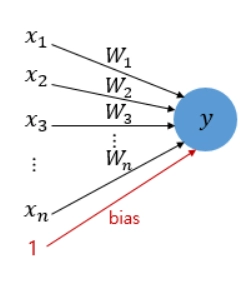  
=> 임계값과 편향은 표현의 차이

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(2) 단층 퍼셉트론과 그 한계 (Single-Layer Perceptron)**</span> 
##### <span style="color: #27baff">   **[단층 퍼셉트론]** <span>
<U>**단순히 입력층과 출력층으로만 이루어진 퍼셉트론**</U>
- 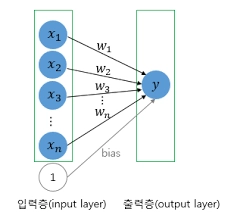  
- 값을 보내는 단계(입력층)와 값을 받아서 출력하는 단계(출력층)으로만 구성

##### <span style="color: #27baff">   **[논리 게이트 구현]** <span>
- 단층 퍼셉트론으로 AND,NAND,OR 게이트 구현가능
- 논리 게이트란?
    - 디지털 회로에서 기본적인 논리 연산을 수행하는 데 사용되는 구성 요소
    - n개의 입력값 -> 1개의 출력값

##### <span style="color: #27baff">   **[대표적인 논리 게이트]** <span>
1. **AND gate**
- 입력값이 모두 1인 경우에만 출력값이 1이 나오는 구조

|$x_1$|$x_2$|$y$|
|---|---|---|
|0|0|0|
|0|1|0|
|1|0|0|
|1|1|1|

- AND gate를 만들 수 있는 두개의 가중치와 편향 값 예시
    - [w1,w2,b]=[0.5,0.5,-0.7],[0.5,0.5,-0.8] 등...
    - $y=0.5*x_1+0.5*x_2+(-0.7)$

2. **OR gate**
- 입력값이 모두 0인 경우에 출력값이 0이고, 나머지 경우에는 모두 출력값이 1인 구조

|$x_1$|$x_2$|$y$|
|---|---|---|
|0|0|0|
|0|1|1|
|1|0|1|
|1|1|1|

- OR gate를 만들 수 있는 두개의 가중치와 편향 값 예시
    - [w1,w2,b]=[0.6,0.6,-0.5],[0.5,0.5,-0.3] 등...
    - $y=0.6*x_1+0.6*x_2+(-0.5)$

3. **NAND gate**
- 입력값이 모두 1인 경우에만 출력값이 0이고, 나머지 경우에는 모두 출력값 1인 구조(AND 반대)

|$x_1$|$x_2$|$y$|
|---|---|---|
|0|0|1|
|0|1|1|
|1|0|1|
|1|1|0|

- AND gate를 만들 수 있는 두개의 가중치와 편향 값 예시
    - [w1,w2,b]=[-0.5,-0.5,0.7],[-0.5,-0.5,0.8] 등...
    - $y=(-0.5)*x_1+(-0.5)*x_2+0.7$

4. **XOR gate**
- 입력값 두개가 서로 다른 값을 갖고 있을 때만 출력값이 1인 구조

|$x_1$|$x_2$|$y$|
|---|---|---|
|0|0|0|
|0|1|1|
|1|0|1|
|1|1|0|

##### <span style="color: #27baff">   **[단층 퍼셉트론의 한계]** <span>
<span style="color: #ff0000">   **XOR gate를 구현할 수 없다!!** <span>
- 이유 : 퍼셉트론은 입력값과 가중치의 선형 결합으로 이루어져 있음  
 => 즉, 직선 하나로 두 영역을 나눌 수 있는 **선형 분류 문제**만 구현 가능

 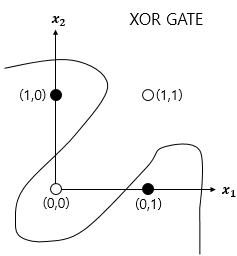

 - XOR 게이트는 직선으로 분리 불가능! = 퍼셉트론 하나로는 구현 할 수 없다  
    => 퍼셉트론을 여러개 결합하자!

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(3) 다층 퍼셉트론 (Multi-Layer Perceptron, MLP)**</span> 
- XOR gate는 AND,NAND,OR gate를 조합하면 만들 수 있다.  
  = 퍼셉트론의 층을 더 쌓으면 구현 가능하다!  
  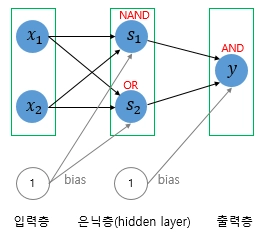  
- 중간에 층을 추가하여 (입력층 + 하나 이상의 은닉층 + 출력층)으로 구성
- 은닉층은 훨씬 많아질 수 있음
- 두개 이상의 은닉층을 갖는 다층 퍼셉트론이 딥러닝의 시초 모델로 발전
    - 심층신경망 (Deep Neural Network, DNN) = 은닉층이 2개 이상인 신경망
    - 딥러닝 (Deep Learning) = 심층 신경망을 학습시킴 (가중치를 스스로 찾도록)


### <span style="color: #000000;background-color: #ffdba4">**2. 딥러닝 모델은 어떻게 학습할까?**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(1) 순전파와 역전파 (Forward & Backward Propagation)**</span> 
##### <span style="color: #27baff">   **[딥러닝 학습 알고리즘의 기본 구조]** <span>
1. 순전파를 통해 입력값으로부터 예측 수행
2. 오차 계산을 통해 예측 정확도 측정
3. 역전파를 통해 출력층에 다시 입력층 방향으로 오차 전달
4. 가중치 업데이트
5. 1~4 반복

- 순전파 : 입력층 -> 정답
- 역전파 : 정답 -> 입력층

##### <span style="color: #27baff">   **[연쇄 법칙 (Chain Rule)]** <span>
- 순전파/역전파는 **연쇄법칙**을 통해 일어남
- 연쇄법칙 : <U>**합성함수의 미분은 각 합수의 미분의 곱으로 나타낼 수 있다는 법칙**</U>
    - 각 층이 다음 층에 미친 영향을 순서대로 곱함 -> 각 입력값이 최종 출력에 얼마나 영향을 미쳤는지 확인 가능
- 필요성
    - 딥러닝 모델의 성능을 높이려면 오차를 줄여야함
    - 이를 위해 역전파 과정에서 각 가중치가 최종 손실에 얼마나 기여했는지 계산해야 함
- 수식
    - A->B->C의 구조 (예시)
    - A가 C에 미친 영향은 직접 계산 X, 다음과 같이 분해해서 계산  
        - $\frac{∂C}{∂A}=\frac{∂C}{∂B}×\frac{∂B}{∂A}$
        - A->C 영행 = B->C의 영향 * A->B의 영향
    - 은닉층이 더 많아져도 원리는 동일

##### <span style="color: #27baff">   **[기울기 소실 문제(Vanishing Gradient Problem)]** <span>
- 만약 은닉층도 엄청 많고, 각 단계마다 미분값이 1보다 작다면?  
    => 한없이 0에 가까워짐  
    => <span style="color: #ff0000">   **기울기들을 계속해서 곱했는데 결국 기울기가 0이 되는 문제 발생!!** <span> = **기울기 소실 문제**
- 앞쪽 층의 가중치가 거의 업데이트되지 않아서 학습이 제대로 되지 않음

##### <span style="color: #27baff">   **[전체적인 흐름 정리]** <span>
1. 순전파 = 예측하기
    - 입력값이 각 층을 통과하면 예측값이 나옴
    - $x->가중치 w_1->가중치 w_2-> y$
2. 손실 계산 = 얼마나 틀렸는지 측정하기
    - 예측값과 실제 정답을 비교해서 오차(손실) 계산
    - 손실값 = (예측값-실제값)^2
3. 역전파 = 책임 추적하기 (연쇄법칙 사용)
    - 손실이 계산되면 출력층부터 거꾸로 거슬러 올라가며 각 가중치가 손실에 얼마나 기여했는지 계산
    - 손실 L <- 가중치 w2의 책임은? <- 가중치 W1의 책임은?
    - 이때 w1은 손실 L에 직접 연결 X, w2를 통해 간접 연결  
        => w1의 책임을 구하려면 연쇄 법칙 사용해야함
4. 가중치 업데이트 = 수정하기
    - 계산값을 바탕으로 가중치를 조금씩 수정
    - 이 과정 반복->모델의 정확도가 올라감

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(2) 손실 함수 (Loss Function)**</span> 
##### <span style="color: #27baff">   **[손실함수란?]** <span>
- <U>**실제값(정답)과 예측값(출력값)의 차이를 계산하는 데에 사용되는 함수**</U>
- 일반적으로 회귀에서는 평균 제곱오차, 분류에서는 크로스 엔트로피 오차 사용

##### <span style="color: #27baff">   **[손실함수의 종류]** <span>
##### **1. 평균 제곱 오차(Mean Squarred Error, MSE)**  
$\frac{1}{N}\sum(y-\hat{y})^2 \ \ \ \ \ \ (y: 실제값,\ \ \hat{y} : 예측값)$  
- 예측 값이 연속적이고, 예측값과 실제 값 간의 차이를 직접적으로 측정하는 회귀 문제에 적합  

##### **2. 이진 크로스 엔트로피(Binary Cross-Entropy Loss, BCE)**  
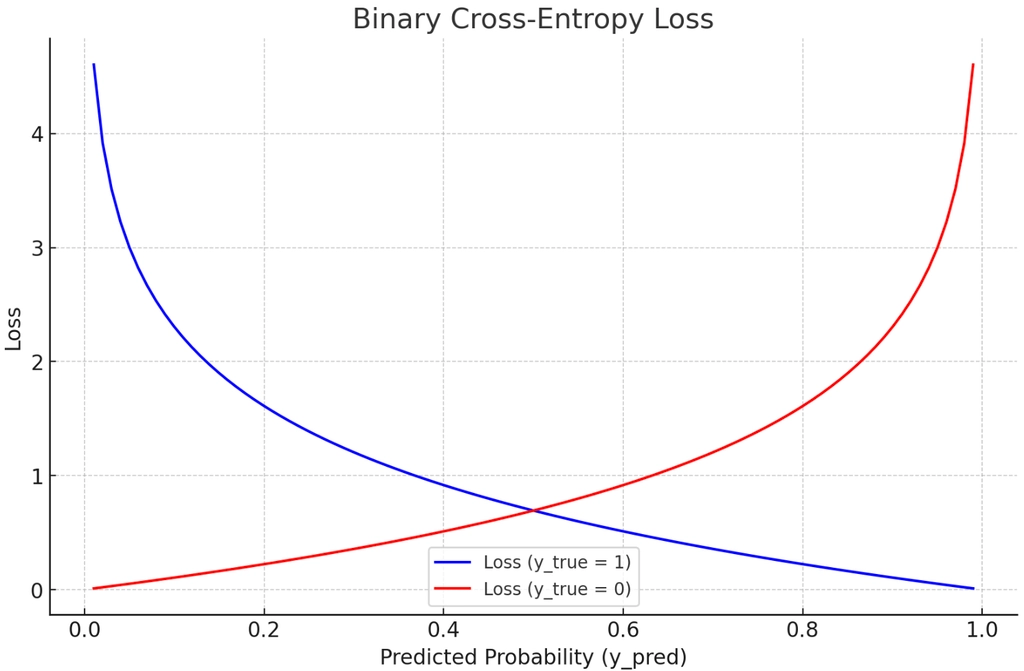  
$L= -(y \log \hat{y} + (1-y) \log(1-\hat{y}))$  
$y : 실제값(0,1)이진값,\ \ \hat{y} : 예측값(확률)$  
- 이진 분류 문제(로지스틱 회귀)에서 사용
- 얼마나 확신을 가지고 예측했는지도 loss에 반영  

##### **3. 크로스 엔트로피 오차 (Cross Entropy Error, CEE)**   
$-\sum y \log \hat{y}$  
$y : 원-핫 인코딩\ 값 (1,0),\ \ \hat{y} : 예측값(확률)$  
- 다중 클래스 분류 문제에서 예측 확률이 실제 클래스와 얼마나 일치하는지를 평가하는 데 적합
- 두 확률 분포(진짜 분포/예측 분포)의 유사도를 측정하는 뎅에 유용

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(3) 활성화 함수(Activation Function)**</span> 
##### <span style="color: #27baff">   **[활성화 함수란?]** <span>
- <U>**각 층의 출력값에 비선형성을 추가해서 신경망이 복잡한 패턴도 학습할 수 있게 해주는 함수**</U>
- 신경망의 계산 구조
    - $wx+b$ -> **활성화 함수**-> 출력값
- 활성화함수가 없으면 층을 아무리 쌓아도 결국 선형 계산 반복에 불과

|  | **단층 퍼셉프론** | **다층 퍼셉트론** |
| --- | --- | --- |
| **활성화 함수** | 계단 함수 | Sigmoid, ReLU 등 |
| **출력값** | 0 또는 1 (이진 출력) | 연속적인 값 (확률 또는 실수) |
| **특징** | 선형 문제만 풀 수 있음 | 복잡한 비선형 문제도 학습 가능 |

##### <span style="color: #27baff">   **[계단함수(Heaviside Step Function)]** <span>
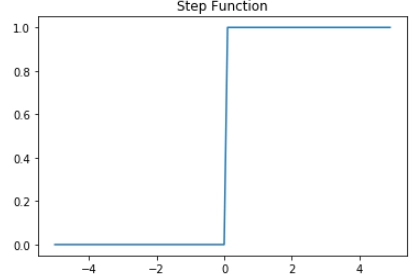  
$h(x) = \begin{cases} 1 & (x \geq 0) \\ 0 & (x < 0) \end{cases}$
- 입력값과 가중치의 곱을 모두 더한 뒤, 그 합이 특정 기준(임계값)을 넘으면 1, 아니면 0 출력
- 주로 단층 퍼셉트론에서 사용
- 임계값 : 뉴런이 얼마나 쉽게 활성화되는지 제어
- 가중치 : 각 입력 신호가 결과에 미치는 영향력 제어

##### <span style="color: #27baff">   **[시그모이드 함수]** <span>
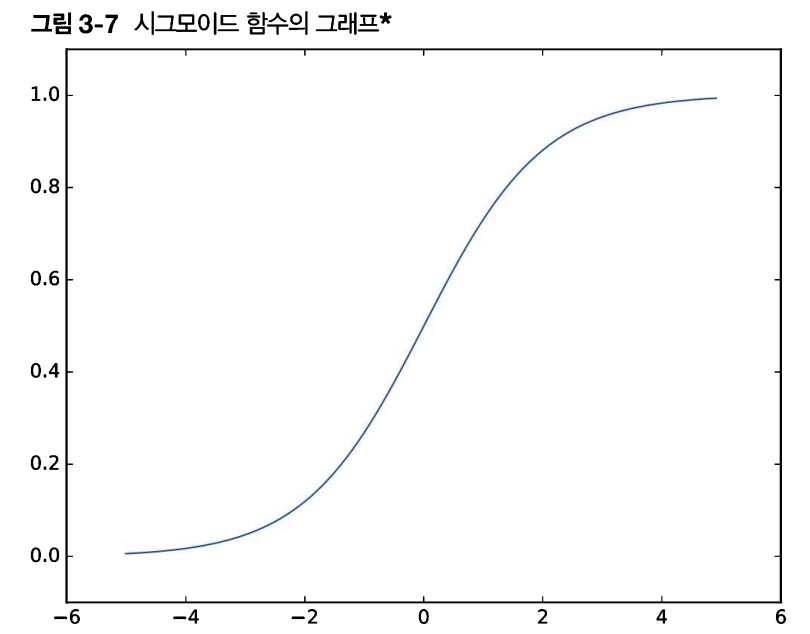  
$f(x)=\frac{1}{1+e^{−x}}$  
- 입력 신호를 0과 1사이의 연속적인 값으로 변환하는 비선형 함수
- 계단 함수와의 차이점
    - 출력값의 형태
    - 얼마나 확실한지 표현 가능

##### <span style="color: #27baff">   **[ReLU 함수]** <span>  
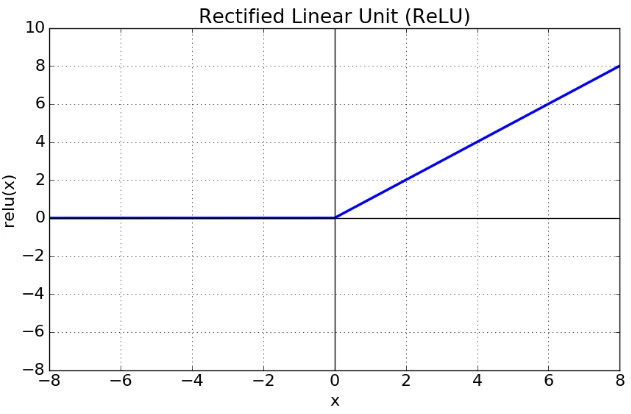  
$f(x)=max(0,x)$  
- 입력값이 양수면 그대로, 아니면 0 출력
- 딥러닝에서 가장 많이 사용
    - 계산이 간단하고 효율적 - 연산 속도가 빠름
    - 비선형성 제공
    - 기울기 소실 문제 완화
        - 양수구간에서 미분값이 항상 1 -> 역전파가 안정적으로 전달

##### <span style="color: #27baff">   **[Tanh(쌍곡탄젠트)함수]** <span>
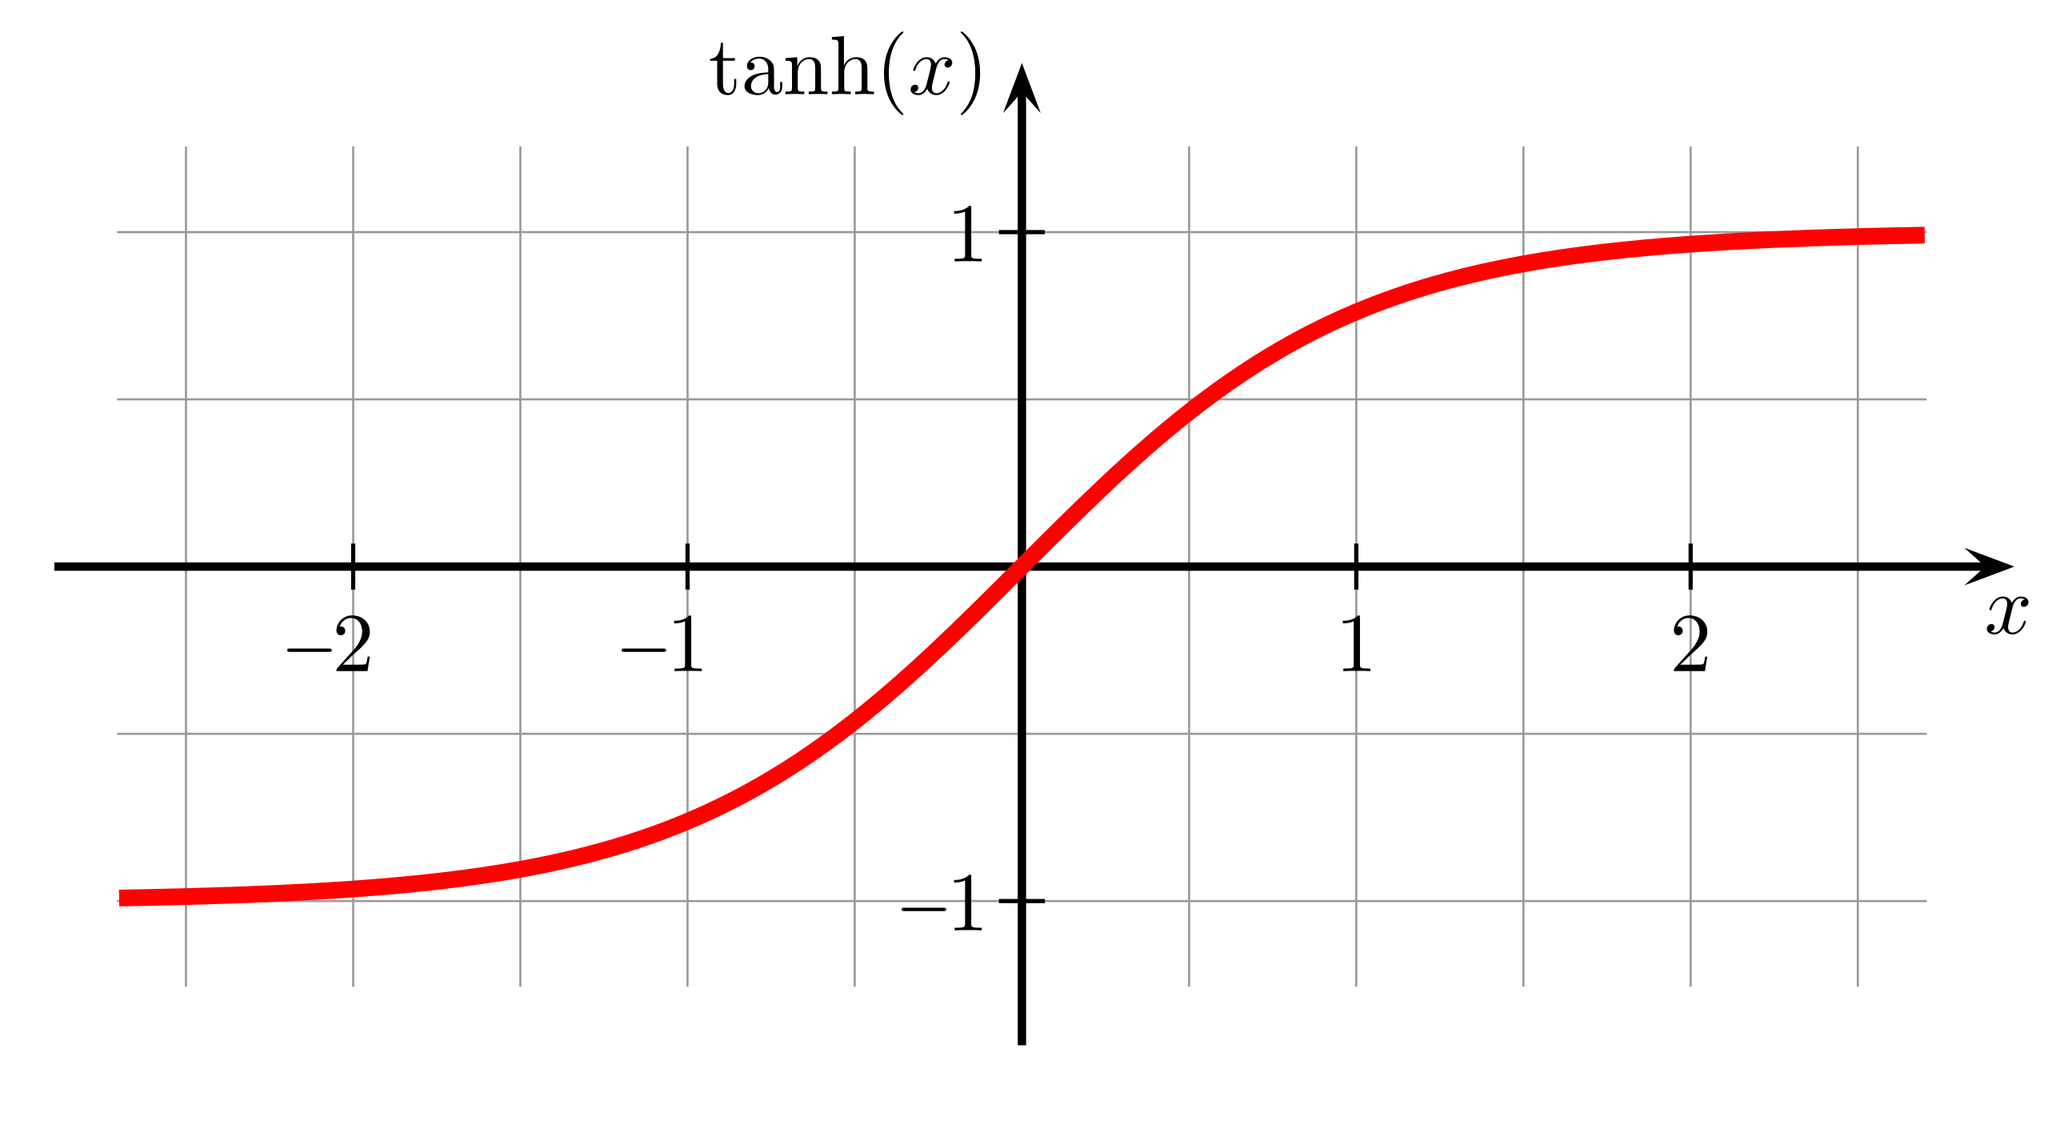  
$f(x)=tanh(x)=\frac{e^x-e^{−x}}{e^x+e^{−x}}$  
- 시그모이드 함수의 변형
- 출력값 범위 : -1~1
- 입력값의 중심을 0으로 맞추고 싶을 때 사용 -> 가중치 업데이트가 더 안정적
- 기울기 소실 문제 발생

##### <span style="color: #27baff">   **[Softmax 함수]** <span>
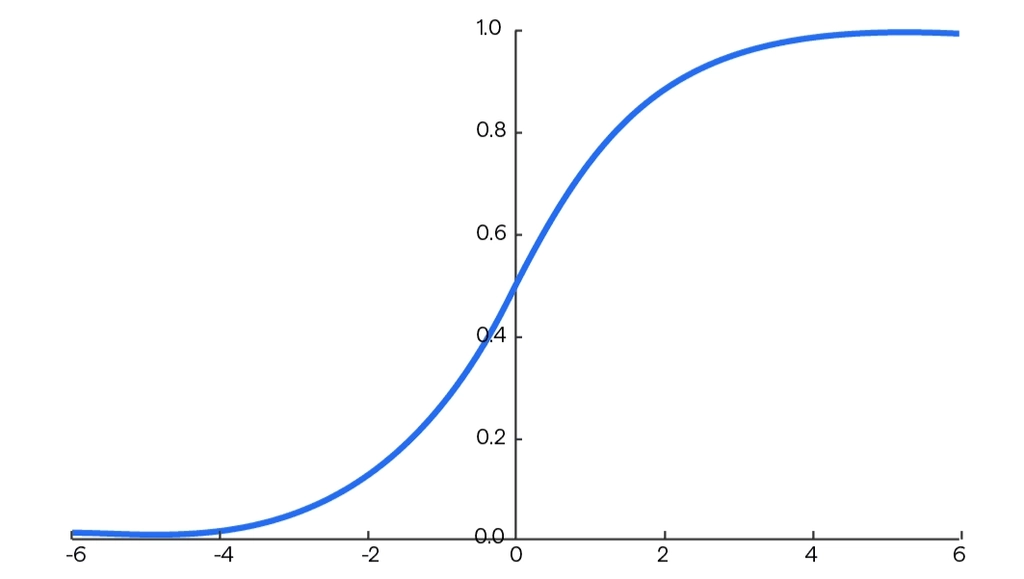  
$f(x_i)=\frac{e^{x_i}}{∑_je^{x_j}}$
- 각 클래스에 대한 출력값을 확률로 변환하는 함수
- 다중 클래스 분류 문제의 출력층으로 사용
    - 크로스 엔트로피 손실 함수와 조합이 가장 표준적인 다중 클래스 분류 조합

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(4) 경사하강법 (Gradient Descent)**</span> 
##### <span style="color: #27baff">   **[기초 지식]** <span>
- 경사하강법 : 오차를 가장 작게 만드는 가중치와 편향을 찾는 방법
- 학습과정에서 데이터를 효율적으로 사용하기 위해 배치 필요

##### 1. 배치(Batch)
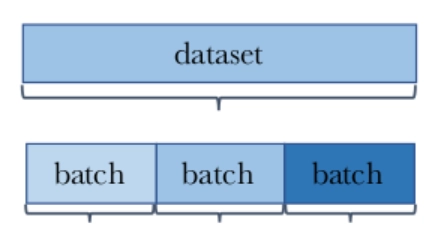  
- 매개변수를 조정하기 위해 사용하는 데이터의 묶음
- 사용자가 임의로 정할 수 있는 하이퍼파라미터

##### 2. 에포크(Epoch)
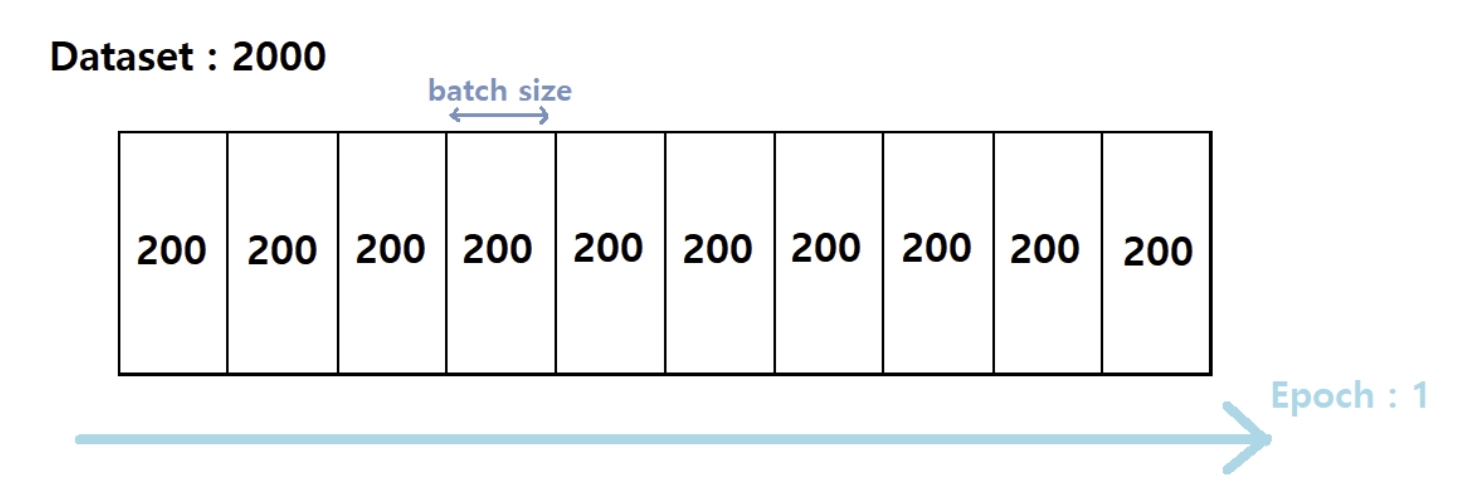  
- 모든 데이터셋을 학습하는 횟수

##### 3. 이터레이션(Iteration) 또는 스텝(Step)
- 한번의 에포크를 끝내기 위해서 필요한 배치의 수
- 1 에포크에서 다루는 데이터의 수 = 배치의 크기 * 이터레이션(스텝)

##### <span style="color: #27baff">   **[배치 경사하강법]** <span>
- **<U>가장 기본적인 경사하강법으로, 오차를 구할 때 전체 데이털르 한 묶음으로 묶음(배치 크기 = 데이터 크기)</U>**
- 특징
    - 전체 데이터를 통해 학습시키기 때문에, 업데이트 횟수가 적음(1 Epoch 당 1 업데이트)
    - 메모리 많이 필요
    - 항상 같은 데이터(전체)에 대해 경사를 구하므로 수렴이 안정적

##### <span style="color: #27baff">   **[배치 크기가 1인 확률적 경사하강법(Stochastic Gradient Descent, SGD)]** <span>
- <U>**매개변수 값을 조정할 때 랜덤으로 선택된 하나의 데이터에 대해서만 계산**</U>
- 시간이 오래 걸리는 기존의 경사하강법의 단점 보완
- 특징
    - 자원이 적은 컴퓨터에서도 쉽게 사용 가능
    - 매개변수의 변경폭이 불안정하고, 정확도가 낮을 수 있음

##### <span style="color: #27baff">   **[미니 배치 경사하강법(Mini-Batch Gradient Descent)]** <span>
- <U>**배치 크기를 적절히 지정하여 해당 데이터 개수만큼에 대해 매개 변수의 값을 조정**</U>
- 정확도가 낮은 배치크기가 1인 경사하강법과 메모리 부족 문제가 있는 기존 경사하강법의 단점 보완
- 전체 데이터를 계산하는 것보다 빠르고, 배치 크기가 1인 경사하강법보다 안정적  
    => 가장 많이 사용되는 경사 하강법
- 배치 사이즈 정하는 방법
    - 일반적으로 $2^n$에 해당하는 숫자로 선택
    - 기본값은 32

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(5) 옵티마이저(Optimizer)**</span> 
- 경사하강법을 더 효율적이고 안정적으로 수행하기 위해서 필요  
    => 옵티마이저를 통해 더 효과적인 최솟값을 찾을 수 있음

##### <span style="color: #27baff">   **[모멘텀(Momentum)]** <span>
- <U>**변수가 가던 방향으로 계속 가도록 속도를 추가함**</U>
    - 관성을 응용한 방법
    - 경사하강법 + 관성
- 경사하강법에서 계산된 접선의 기울기에 바로 한 시점 전의 접선의 기울기값을 일정 비율만큼 반영  
    -> local minima에 빠지더라도 빠져나올 수 있음

##### <span style="color: #27baff">   **[알엠에스프롭(RMSProp)]** <span>
- 기울기가 큰 방향에서는 너무 많이, 작은 방향에서는 너무 작게 이동하는 기존의 경사하강법 문제 해결 => 학습률을 조정하자!
- (예시) 하산할때
    - 급한 경사에서는 속도를 줄이고 완만한 경사에서는 속도를 유지하거나 증가

##### <span style="color: #27baff">   **[아담(Adam)]** <span>
- <U>**RMSProp과 Momentum을 합친, 방향과 스텝 사이즈를 적절하게 합친 방법**</U>
- 방향과 학습률 두 가지를 모두 잡은
- 각 파라미터의 1차 모멘트(기울기의 평균)과 2차 모멘트(기울기의 제곱 평균)을 사용하여 학습률 조정

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(6) 더 넓은 학습을 위해 - 데이터 증강(Data Augmentation)**</span> 
- 현실의 데이터는 다양하게 변형되고 조금씩 바뀌는 경우가 많아서 기존 데이터에서 다양한 변형을 만들어 학습 데이터를 늘리자! => **데이터 증강 필요**
- 데이터 증강이란?
    - 학습 데이터셋에 일부러 다양한 변화를 가하는 것
    - 목적 : 데이터 부족 문제 해결, 모델의 견고함 향상, 과적합 감소
    - 주의점 : 변형된 데이터가 원본의 본질적인 특성을 잃지 않아야 하며 태스크에 적절한 증강 방식을 선택해야함
- 데이터 증강 활용
    - 모델 성능의 향상
    - 데이터 의존성 감소
    - 과적합 완화
    - 데이터 프라이버시 보호